# 04 — EOS model misspecification

This notebook uses the same mock catalog, PE samples, and injections as notebook 03, but changes the EOS functional form used in the hierarchical inference.

The matched order from notebook 03 is loaded from disk. Then this notebook runs two additional inferences sequentially:

- an underfit linear EOS model, `log Lambda(m)` polynomial order 1;
- an over-flexible EOS model, polynomial order 5.

The diagnostics compare the matched result, the linear result, and the fifth-order result in function space and in the inferred mass distribution.

## Colab setup

In [1]:
# Run this cell only on Colab.
# !git clone https://github.com/Mik3M4n/ns-eos-population-tutorial.git
# %cd ns-eos-population-tutorial
# !pip install -r requirements.txt

## Imports and paths

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.scipy as jsp

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

import arviz as az

from astropy.cosmology import Planck18 as cosmology
from astropy.constants import c

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data/processed"
figures_dir = project_root / "figures"
results_dir = project_root / "results"

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

C_KM_S = c.to("km/s").value

## Runtime choices

In [2]:


# EOS orders to run in this notebook.
inference_eos_orders = [1, 7]

# These control runtime only. They do not change the generated catalog.
n_events_use = 20
n_pe_use = 500
n_injections_use = 2_000

# NumPyro settings.
num_warmup = 200
num_samples = 200
num_chains = 2
rng_seed = 123

# Optional hard cuts. Use these to test with/without the constraints.
apply_hard_eos_physical_prior = False
apply_hard_mc_variance_cut = False

# GWTC-style Monte Carlo likelihood variance cut.
max_log_likelihood_variance = 1.0


## Load data from previous notebooks

In [3]:
# Tagged inputs from notebooks 00--02.
# Edit these filenames if you changed the upstream tags.
eos_fit_filename = "eos_fit__bsk24_m1p00_2p25_poly5.npz"
population_filename = "intrinsic_population__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993.npz"
detected_filename = "detected_events__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.npz"
pe_filename = "mock_pe_samples__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.npz"
injections_filename = "injections__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871.npz"

eos_fit = np.load(processed_dir / eos_fit_filename)
intrinsic = np.load(processed_dir / population_filename)
detected = np.load(processed_dir / detected_filename)
pe = np.load(processed_dir / pe_filename)
injections = np.load(processed_dir / injections_filename)

def read_npz_string(data, key):
    value = data[key]
    if np.asarray(value).shape == ():
        return str(value.item())
    return str(value)

eos_tag = read_npz_string(eos_fit, "eos_tag")
eos_base_tag = read_npz_string(eos_fit, "eos_base_tag") if "eos_base_tag" in eos_fit else ""
fit_mass_tag = read_npz_string(eos_fit, "fit_mass_tag") if "fit_mass_tag" in eos_fit else ""
pop_tag = read_npz_string(intrinsic, "pop_tag")
detpe_tag = read_npz_string(detected, "detpe_tag")
inj_tag = read_npz_string(injections, "inj_tag")

n_events_available = detected["m1_det"].shape[0]
n_pe_available = pe["m1_det"].shape[1]
n_injections_available = injections["m1_det"].shape[0]
n_inj_drawn_total = int(injections["n_inj_drawn"])

if n_injections_use == -1:
    n_injections_use = n_injections_available

inf_tag = (
    f"inf_nev{n_events_use}_npe{n_pe_use}_ninj{n_injections_use}"
    f"_w{num_warmup}_s{num_samples}_c{num_chains}_seed{rng_seed}"
)
base_tag = f"{eos_tag}__{pop_tag}__{detpe_tag}__{inj_tag}"
matched_run_tag = f"{base_tag}__{inf_tag}"
matched_idata_filename = f"inferencedata__{matched_run_tag}.nc"

fit_min = float(eos_fit["fit_min"])
fit_max = float(eos_fit["fit_max"])
truth_eos_order = int(eos_fit["chosen_order"])
eos_coeffs_fit = np.array(eos_fit["chosen_coeffs"])
edge_pdf_value = float(intrinsic["edge_pdf_value"])

print(f"EOS tag: {eos_tag}")
print(f"Population tag: {pop_tag}")
print(f"Detection/PE tag: {detpe_tag}")
print(f"Injection tag: {inj_tag}")
print(f"Matched run tag expected from notebook 03: {matched_run_tag}")
print()
print(f"Available events: {n_events_available}")
print(f"Available PE samples per event: {n_pe_available}")
print(f"Available detected injections: {n_injections_available}")
print(f"Total injections drawn in notebook 02: {n_inj_drawn_total}")
print(f"Truth EOS order: {truth_eos_order}")
print("Truth EOS coefficients, highest power first:")
print(eos_coeffs_fit)

EOS tag: bsk24_m1p00_2p25_poly5
Population tag: smoothbox_md_z20_n100000_seed31031993
Detection/PE tag: det_rho80_thr8_nev100_pe5000_seed1871
Injection tag: inj_n200000_z20_edge0p001_seed1871
Matched run tag expected from notebook 03: bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123

Available events: 100
Available PE samples per event: 5000
Available detected injections: 41709
Total injections drawn in notebook 02: 200000
Truth EOS order: 5
Truth EOS coefficients, highest power first:
[  -3.64658384   27.9814013   -85.58976541  130.61215129 -103.79720222
   42.55491452]


## Select a smaller dataset for fast runs

In [4]:
rng = np.random.default_rng(rng_seed)

if n_events_use > n_events_available:
    raise ValueError(f"n_events_use={n_events_use} exceeds available events={n_events_available}")
if n_pe_use > n_pe_available:
    raise ValueError(f"n_pe_use={n_pe_use} exceeds available PE samples per event={n_pe_available}")
if n_injections_use > n_injections_available:
    raise ValueError(f"n_injections_use={n_injections_use} exceeds available detected injections={n_injections_available}")

event_idx = np.arange(n_events_available)[:n_events_use]
pe_idx = rng.choice(n_pe_available, size=n_pe_use, replace=False)
inj_idx = rng.choice(n_injections_available, size=n_injections_use, replace=False)

pe_m1_det = pe["m1_det"][event_idx][:, pe_idx]
pe_m2_det = pe["m2_det"][event_idx][:, pe_idx]
pe_d_l = pe["d_l"][event_idx][:, pe_idx]

obs_log_lambdatilde = pe["obs_log_lambdatilde"][event_idx]
sigma_log_lambdatilde = pe["sigma_log_lambdatilde"][event_idx]

true_m1 = detected["m1"][event_idx]
true_m2 = detected["m2"][event_idx]
true_mchirp = (true_m1 * true_m2) ** (3.0 / 5.0) / (true_m1 + true_m2) ** (1.0 / 5.0)

inj_m1_det = injections["m1_det"][inj_idx]
inj_m2_det = injections["m2_det"][inj_idx]
inj_d_l = injections["d_l"][inj_idx]
inj_log_p_draw = injections["log_p_draw"][inj_idx]

# We use only a random subset of found injections.  The selection estimator
# must therefore estimate the full found-injection sum by multiplying the
# subset sum by this factor.
n_inj_drawn = n_inj_drawn_total
inj_subset_factor = n_injections_available / n_injections_use

print(f"Using events: {n_events_use}")
print(f"Using PE samples per event: {n_pe_use}")
print(f"Using detected injections: {n_injections_use}")
print(f"Detected-injection subset factor: {inj_subset_factor:.6g}")
print(f"Total injections drawn in notebook 02: {n_inj_drawn}")

Using events: 20
Using PE samples per event: 500
Using detected injections: 2000
Detected-injection subset factor: 20.8545
Total injections drawn in notebook 02: 200000


## Load matched result from notebook 03

In [5]:
matched_idata_path = results_dir / matched_idata_filename
matched_idata = az.from_netcdf(matched_idata_path)

print(f"Loaded matched inference result from {matched_idata_path}")

Loaded matched inference result from /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/results/inferencedata__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.nc


## Cosmology grid

In [6]:
z_grid_np = np.linspace(1e-6, 25.0, 6000)
d_l_grid_np = cosmology.luminosity_distance(z_grid_np).value
dc_grid_np = cosmology.comoving_distance(z_grid_np).value
Hz_grid_np = cosmology.H(z_grid_np).value

log_dV_dz_grid_np = np.log(4.0 * np.pi) + np.log(C_KM_S) - np.log(Hz_grid_np) + 2.0 * np.log(dc_grid_np)
ddL_dz_grid_np = dc_grid_np + (1.0 + z_grid_np) * C_KM_S / Hz_grid_np
log_ddL_dz_grid_np = np.log(ddL_dz_grid_np)

z_grid = jnp.asarray(z_grid_np)
d_l_grid = jnp.asarray(d_l_grid_np)
log_dV_dz_grid = jnp.asarray(log_dV_dz_grid_np)
log_ddL_dz_grid = jnp.asarray(log_ddL_dz_grid_np)

def z_from_d_l_jax(d_l):
    return jnp.interp(d_l, d_l_grid, z_grid)

def interp_log_dV_dz(z):
    return jnp.interp(z, z_grid, log_dV_dz_grid)

def interp_log_ddL_dz(z):
    return jnp.interp(z, z_grid, log_ddL_dz_grid)


## Population model

In [7]:
mass_grid = jnp.linspace(fit_min, fit_max, 1000)

def sigmoid_jax(x):
    return jax.nn.sigmoid(x)

def bounded_smooth_mass_unnorm(m, m_min, m_max, edge_width):
    logit_edge = jnp.log((1.0 - edge_pdf_value) / edge_pdf_value)
    edge_scale = edge_width / logit_edge
    left = sigmoid_jax((m - m_min - edge_width) / edge_scale)
    right = sigmoid_jax((m_max - edge_width - m) / edge_scale)
    return left * right

def log_mass_pdf(m, m_min, m_max, edge_width):
    pdf_grid = bounded_smooth_mass_unnorm(mass_grid, m_min, m_max, edge_width)
    norm = jnp.trapezoid(pdf_grid, mass_grid)

    pdf = bounded_smooth_mass_unnorm(m, m_min, m_max, edge_width) / norm

    in_support = (m >= fit_min) & (m <= fit_max)
    return jnp.where(
        in_support,
        jnp.log(jnp.maximum(pdf, 1e-300)),
        -1e30,
    )

def merger_rate_density_jax(z, alpha_z, beta_z, z_p):
    numerator = (1.0 + z) ** alpha_z
    denominator = 1.0 + ((1.0 + z) / (1.0 + z_p)) ** (alpha_z + beta_z)
    return numerator / denominator

def log_redshift_pdf(z, alpha_z, beta_z, z_p):
    rate_grid = merger_rate_density_jax(z_grid, alpha_z, beta_z, z_p)
    integrand_grid = rate_grid * jnp.exp(log_dV_dz_grid) / (1.0 + z_grid)
    norm = jnp.trapezoid(integrand_grid, z_grid)

    log_rate = jnp.log(merger_rate_density_jax(z, alpha_z, beta_z, z_p))
    return log_rate + interp_log_dV_dz(z) - jnp.log1p(z) - jnp.log(norm)

def log_pop_source(m1, m2, z, m_min, m_max, edge_width, alpha_z, beta_z, z_p):
    return (
        jnp.log(2.0)
        + log_mass_pdf(m1, m_min, m_max, edge_width)
        + log_mass_pdf(m2, m_min, m_max, edge_width)
        + log_redshift_pdf(z, alpha_z, beta_z, z_p)
    )


## EOS model and deterministic tidal constraint

In [8]:
def polyval_jax(coeffs, x):
    y = jnp.zeros_like(x)
    for c in coeffs:
        y = y * x + c
    return y

def lambda_of_mass_jax(m, coeffs):
    return jnp.exp(polyval_jax(coeffs, m))

def lambda_tilde_jax(m1, m2, lambda1, lambda2):
    return (16.0 / 13.0) * (
        (m1 + 12.0 * m2) * m1**4 * lambda1
        + (m2 + 12.0 * m1) * m2**4 * lambda2
    ) / (m1 + m2) ** 5

def log_tidal_likelihood(log_lambda_tilde_eos, obs_log_lambdatilde, sigma):
    return dist.Normal(obs_log_lambdatilde[:, None], sigma[:, None]).log_prob(log_lambda_tilde_eos)


## Parameter configuration

In [9]:
m_min_true = float(intrinsic["m_min_true"])
m_max_true = float(intrinsic["m_max_true"])
edge_width_true = float(intrinsic["edge_width_true"])
alpha_z_true = float(intrinsic["alpha_z"])
beta_z_true = float(intrinsic["beta_z"])
z_p_true = float(intrinsic["z_p"])

def fit_truth_coeffs_to_order(order):
    m = np.linspace(fit_min, fit_max, 500)
    log_lambda_truth = np.polyval(eos_coeffs_fit, m)
    return np.polyfit(m, log_lambda_truth, order)

def make_param_config(inference_eos_order):
    coeff_center = fit_truth_coeffs_to_order(inference_eos_order)

    cfg = {
        "m_min": {
            "sample": True,
            "fixed": m_min_true,
            "prior": ("uniform", fit_min - 0.05, fit_min + 0.05),
            "init": m_min_true,
        },
        "m_max": {
            "sample": True,
            "fixed": m_max_true,
            "prior": ("uniform", fit_max - 0.05, fit_max + 0.05),
            "init": m_max_true,
        },
        "edge_width": {
            "sample": False,
            "fixed": edge_width_true,
            "prior": ("uniform", 0.01, 0.15),
            "init": edge_width_true,
        },
        "alpha_z": {
            "sample": True,
            "fixed": alpha_z_true,
            "prior": ("uniform", 1.0, 5.0),
            "init": alpha_z_true,
        },
        "beta_z": {
            "sample": True,
            "fixed": beta_z_true,
            "prior": ("uniform", 1.0, 5.0),
            "init": beta_z_true,
        },
        "z_p": {
            "sample": True,
            "fixed": z_p_true,
            "prior": ("uniform", 1.0, 3.0),
            "init": z_p_true,
        },
    }

    for k, coeff in enumerate(coeff_center):
        width = 0.02 * abs(float(coeff)) + 0.01
        cfg[f"eos_a{k}"] = {
            "sample": True,
            "fixed": float(coeff),
            "prior": ("normal", float(coeff), width),
            "init": float(coeff),
        }

    return cfg, coeff_center

## Rate-marginalized likelihood

In [10]:
pe_m1_det_j = jnp.asarray(pe_m1_det)
pe_m2_det_j = jnp.asarray(pe_m2_det)
pe_d_l_j = jnp.asarray(pe_d_l)

obs_log_lambdatilde_j = jnp.asarray(obs_log_lambdatilde)
sigma_log_lambdatilde_j = jnp.asarray(sigma_log_lambdatilde)

inj_m1_det_j = jnp.asarray(inj_m1_det)
inj_m2_det_j = jnp.asarray(inj_m2_det)
inj_d_l_j = jnp.asarray(inj_d_l)
inj_log_p_draw_j = jnp.asarray(inj_log_p_draw)

def sample_parameter(name, cfg):
    prior = cfg["prior"]
    if cfg["sample"]:
        if prior[0] == "uniform":
            return numpyro.sample(name, dist.Uniform(prior[1], prior[2]))
        if prior[0] == "normal":
            return numpyro.sample(name, dist.Normal(prior[1], prior[2]))
        raise ValueError(f"Unknown prior type for {name}: {prior[0]}")
    return jnp.asarray(cfg["fixed"])

def relative_variance_from_logweights(logw, axis):
    max_logw = jnp.max(logw, axis=axis, keepdims=True)
    w = jnp.exp(logw - max_logw)

    n = logw.shape[axis]
    mean_w = jnp.mean(w, axis=axis, keepdims=True)
    var_mean = jnp.sum((w - mean_w) ** 2, axis=axis) / (n * (n - 1))
    mean_w_flat = jnp.squeeze(mean_w, axis=axis)

    return var_mean / (mean_w_flat ** 2)

def logmeanexp(logw, axis):
    return jsp.special.logsumexp(logw, axis=axis) - jnp.log(logw.shape[axis])



def soft_barrier_lower(x, xmin, width):
    return -jax.nn.softplus((xmin - x) / width)

def soft_barrier_upper(x, xmax, width):
    return -jax.nn.softplus((x - xmax) / width)

    

@jax.jit
def compute_hierarchical_loglike(
    m_min,
    m_max,
    edge_width,
    alpha_z,
    beta_z,
    z_p,
    coeffs,
):
    pe_z = z_from_d_l_jax(pe_d_l_j)
    pe_m1 = pe_m1_det_j / (1.0 + pe_z)
    pe_m2 = pe_m2_det_j / (1.0 + pe_z)

    pe_log_pop_src = log_pop_source(
        pe_m1, pe_m2, pe_z,
        m_min, m_max, edge_width,
        alpha_z, beta_z, z_p,
    )

    pe_log_jac = -2.0 * jnp.log1p(pe_z) - interp_log_ddL_dz(pe_z)
    pe_log_pe_prior = 2.0 * jnp.log(pe_d_l_j)

    pe_lambda1 = lambda_of_mass_jax(pe_m1, coeffs)
    pe_lambda2 = lambda_of_mass_jax(pe_m2, coeffs)
    pe_lambda_tilde_eos = lambda_tilde_jax(pe_m1, pe_m2, pe_lambda1, pe_lambda2)
    pe_log_lambda_tilde_eos = jnp.log(jnp.maximum(pe_lambda_tilde_eos, 1e-300))

    logL_tidal = log_tidal_likelihood(
        pe_log_lambda_tilde_eos,
        obs_log_lambdatilde_j,
        sigma_log_lambdatilde_j,
    )

    log_event_weights = pe_log_pop_src + pe_log_jac - pe_log_pe_prior + logL_tidal
    log_L_events = logmeanexp(log_event_weights, axis=1)
    event_rel_var = relative_variance_from_logweights(log_event_weights, axis=1)

    inj_z = z_from_d_l_jax(inj_d_l_j)
    inj_m1 = inj_m1_det_j / (1.0 + inj_z)
    inj_m2 = inj_m2_det_j / (1.0 + inj_z)

    inj_log_pop_src = log_pop_source(
        inj_m1, inj_m2, inj_z,
        m_min, m_max, edge_width,
        alpha_z, beta_z, z_p,
    )
    inj_log_jac = -2.0 * jnp.log1p(inj_z) - interp_log_ddL_dz(inj_z)
    inj_log_pop_det = inj_log_pop_src + inj_log_jac

    log_inj_weights = inj_log_pop_det - inj_log_p_draw_j

    max_logW = jnp.max(log_inj_weights)
    W_scaled = jnp.exp(log_inj_weights - max_logW)

    sum_W_scaled = jnp.sum(W_scaled)
    sum_W2_scaled = jnp.sum(W_scaled ** 2)

    # Correct for using a random subset of the found injections.
    # The full found-injection sum is estimated as
    # inj_subset_factor times the subset sum.
    xi_scaled = inj_subset_factor * sum_W_scaled / n_inj_drawn
    log_xi = max_logW + jnp.log(inj_subset_factor * sum_W_scaled) - jnp.log(n_inj_drawn)

    # Same correction for the second moment entering the GWTC-style MC variance.
    var_xi_scaled = (
        inj_subset_factor * sum_W2_scaled - n_inj_drawn * xi_scaled ** 2
    ) / (n_inj_drawn * (n_inj_drawn - 1))
    var_xi_scaled = jnp.maximum(var_xi_scaled, 0.0)
    xi_rel_var = var_xi_scaled / (xi_scaled ** 2)

    n_det = pe_m1_det_j.shape[0]
    log_likelihood_variance = jnp.sum(event_rel_var) + n_det**2 * xi_rel_var

    log_likelihood = jnp.sum(log_L_events) - n_det * log_xi

    return (
        log_likelihood,
        log_xi,
        xi_rel_var,
        jnp.sum(event_rel_var),
        log_likelihood_variance,
    )



def hierarchical_model():
    m_min = sample_parameter("m_min", param_config["m_min"])
    m_max = sample_parameter("m_max", param_config["m_max"])
    edge_width = sample_parameter("edge_width", param_config["edge_width"])
    alpha_z = sample_parameter("alpha_z", param_config["alpha_z"])
    beta_z = sample_parameter("beta_z", param_config["beta_z"])
    z_p = sample_parameter("z_p", param_config["z_p"])

    coeffs = []
    for k in range(eos_order + 1):
        coeffs.append(sample_parameter(f"eos_a{k}", param_config[f"eos_a{k}"]))
    coeffs = jnp.stack(coeffs)

    numpyro.factor("mass_order_constraint", jnp.where(m_min < m_max, 0.0, -jnp.inf))

    log_lambda_grid = polyval_jax(coeffs, mass_grid)

    # quick version - makes divergences appear
    eos_valid = (
        jnp.all(jnp.isfinite(log_lambda_grid))
        & jnp.all(log_lambda_grid > jnp.log(0.1))
        & jnp.all(log_lambda_grid < jnp.log(1e5))
        & jnp.all(jnp.diff(log_lambda_grid) < 0.0)
    )
    
    numpyro.deterministic("eos_is_physical", eos_valid)
    if apply_hard_eos_physical_prior:
        numpyro.factor("eos_physical_prior", jnp.where(eos_valid, 0.0, -1e30))

    # lengty version - smooths boundaries
    # log_lambda_min = jnp.log(0.1)
    # log_lambda_max = jnp.log(1e5)
    
    # eos_barrier_width = 0.05
    
    # log_lambda_lower_penalty = jnp.sum(
    #     soft_barrier_lower(log_lambda_grid, log_lambda_min, eos_barrier_width)
    # )
    
    # log_lambda_upper_penalty = jnp.sum(
    #     soft_barrier_upper(log_lambda_grid, log_lambda_max, eos_barrier_width)
    # )
    
    # monotonicity_penalty = jnp.sum(
    #     -jax.nn.softplus(jnp.diff(log_lambda_grid) / eos_barrier_width)
    # )
    
    # numpyro.factor(
    #     "eos_physical_prior",
    #     log_lambda_lower_penalty
    #     + log_lambda_upper_penalty
    #     + monotonicity_penalty,
    # )

    (
        log_likelihood,
        log_xi,
        selection_rel_var,
        sum_event_rel_var,
        log_likelihood_variance,
    ) = compute_hierarchical_loglike(
        m_min,
        m_max,
        edge_width,
        alpha_z,
        beta_z,
        z_p,
        coeffs,
        )

    numpyro.deterministic("log_xi", log_xi)
    numpyro.deterministic("selection_rel_var", selection_rel_var)
    numpyro.deterministic("sum_event_rel_var", sum_event_rel_var)
    numpyro.deterministic("log_likelihood_variance", log_likelihood_variance)
    numpyro.deterministic("log_likelihood_value", log_likelihood)

    numpyro.deterministic(
        "passes_mc_variance_cut",
        log_likelihood_variance < max_log_likelihood_variance,
        )

    if apply_hard_mc_variance_cut:
        numpyro.factor("variance_cut", jnp.where(log_likelihood_variance < max_log_likelihood_variance, 0.0, -1e30))

    # mc_variance_barrier_width = 0.1

    # mc_variance_penalty = -jax.nn.softplus(
    #     (log_likelihood_variance - max_log_likelihood_variance)
    #     / mc_variance_barrier_width
    # )
    
    # numpyro.factor("mc_variance_cut", mc_variance_penalty)

    numpyro.factor("hierarchical_likelihood", log_likelihood)

## Run misspecified EOS inferences

In [11]:
def sample_parameter(name, cfg):
    prior = cfg["prior"]
    if cfg["sample"]:
        if prior[0] == "uniform":
            return numpyro.sample(name, dist.Uniform(prior[1], prior[2]))
        if prior[0] == "normal":
            return numpyro.sample(name, dist.Normal(prior[1], prior[2]))
        raise ValueError(prior[0])
    return cfg["fixed"]

def json_safe(x):
    if isinstance(x, (str, int, float, bool)) or x is None:
        return x
    if isinstance(x, Path):
        return str(x)
    if isinstance(x, np.generic):
        return x.item()
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, tuple):
        return [json_safe(v) for v in x]
    if isinstance(x, list):
        return [json_safe(v) for v in x]
    if isinstance(x, dict):
        return {str(k): json_safe(v) for k, v in x.items()}
    return str(x)

def run_inference_for_eos_order(inference_eos_order, model_label):
    param_config, coeff_center = make_param_config(inference_eos_order)
    eos_model_tag = f"eosmodel_poly{inference_eos_order}"
    run_tag = f"{base_tag}__{eos_model_tag}__{inf_tag}"

    def hierarchical_model():
        m_min = sample_parameter("m_min", param_config["m_min"])
        m_max = sample_parameter("m_max", param_config["m_max"])
        edge_width = sample_parameter("edge_width", param_config["edge_width"])
        alpha_z = sample_parameter("alpha_z", param_config["alpha_z"])
        beta_z = sample_parameter("beta_z", param_config["beta_z"])
        z_p = sample_parameter("z_p", param_config["z_p"])

        coeffs = []
        for k in range(inference_eos_order + 1):
            coeffs.append(sample_parameter(f"eos_a{k}", param_config[f"eos_a{k}"]))
        coeffs = jnp.stack(coeffs)

        numpyro.factor(
            "mass_order_constraint",
            jnp.where(m_min < m_max, 0.0, -1e30),
        )

        log_lambda_grid = polyval_jax(coeffs, mass_grid)
        eos_valid = (
            jnp.all(jnp.isfinite(log_lambda_grid))
            & jnp.all(log_lambda_grid > jnp.log(0.1))
            & jnp.all(log_lambda_grid < jnp.log(1e5))
            & jnp.all(jnp.diff(log_lambda_grid) < 0.0)
        )
        numpyro.deterministic("eos_physical_valid", eos_valid)
        if apply_hard_eos_physical_prior:
            numpyro.factor("eos_physical_prior", jnp.where(eos_valid, 0.0, -1e30))

        (
            log_likelihood,
            log_xi,
            selection_rel_var,
            sum_event_rel_var,
            log_likelihood_variance,
        ) = compute_hierarchical_loglike(
            m_min,
            m_max,
            edge_width,
            alpha_z,
            beta_z,
            z_p,
            coeffs,
        )

        numpyro.deterministic("log_xi", log_xi)
        numpyro.deterministic("selection_rel_var", selection_rel_var)
        numpyro.deterministic("sum_event_rel_var", sum_event_rel_var)
        numpyro.deterministic("log_likelihood_variance", log_likelihood_variance)
        numpyro.deterministic("log_likelihood_value", log_likelihood)
        numpyro.deterministic(
            "passes_mc_variance_cut",
            log_likelihood_variance < max_log_likelihood_variance,
        )

        if apply_hard_mc_variance_cut:
            numpyro.factor(
                "variance_cut",
                jnp.where(log_likelihood_variance < max_log_likelihood_variance, 0.0, -1e30),
            )

        numpyro.factor("hierarchical_likelihood", log_likelihood)

    init_values = {
        name: cfg["init"]
        for name, cfg in param_config.items()
        if cfg["sample"]
    }

    nuts = NUTS(
        hierarchical_model,
        init_strategy=init_to_value(values=init_values),
        target_accept_prob=0.85,
    )
    mcmc = MCMC(
        nuts,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
    )

    print(f"Running {model_label}: EOS order {inference_eos_order}")
    mcmc.run(jax.random.PRNGKey(rng_seed + inference_eos_order))
    mcmc.print_summary()

    idata = az.from_numpyro(mcmc)
    summary = az.summary(idata, round_to=3)

    summary_path = results_dir / f"summary__{run_tag}.csv"
    idata_path = results_dir / f"inferencedata__{run_tag}.nc"
    posterior_path = results_dir / f"posterior_samples__{run_tag}.npz"
    config_path = results_dir / f"config__{run_tag}.json"

    summary.to_csv(summary_path)
    idata.to_netcdf(idata_path)

    posterior_flat = mcmc.get_samples(group_by_chain=False)
    np.savez(
        posterior_path,
        **{name: np.asarray(value) for name, value in posterior_flat.items()},
    )

    run_config = {
        "run_tag": run_tag,
        "base_tag": base_tag,
        "eos_model_tag": eos_model_tag,
        "model_label": model_label,
        "inference_eos_order": inference_eos_order,
        "truth_eos_order": truth_eos_order,
        "eos_tag": eos_tag,
        "pop_tag": pop_tag,
        "detpe_tag": detpe_tag,
        "inj_tag": inj_tag,
        "inf_tag": inf_tag,
        "input_files": {
            "eos_fit_filename": eos_fit_filename,
            "population_filename": population_filename,
            "detected_filename": detected_filename,
            "pe_filename": pe_filename,
            "injections_filename": injections_filename,
            "matched_idata_filename": matched_idata_filename,
        },
        "runtime": {
            "n_events_use": n_events_use,
            "n_pe_use": n_pe_use,
            "n_injections_use": n_injections_use,
            "n_injections_available": n_injections_available,
            "inj_subset_factor": inj_subset_factor,
            "n_inj_drawn": n_inj_drawn,
            "num_warmup": num_warmup,
            "num_samples": num_samples,
            "num_chains": num_chains,
            "rng_seed": rng_seed,
            "apply_hard_eos_physical_prior": apply_hard_eos_physical_prior,
            "apply_hard_mc_variance_cut": apply_hard_mc_variance_cut,
            "max_log_likelihood_variance": max_log_likelihood_variance,
        },
        "truth": {
            "fit_min": fit_min,
            "fit_max": fit_max,
            "eos_order": truth_eos_order,
            "eos_coeffs_fit": eos_coeffs_fit,
            "m_min_true": m_min_true,
            "m_max_true": m_max_true,
            "edge_width_true": edge_width_true,
            "alpha_z_true": alpha_z_true,
            "beta_z_true": beta_z_true,
            "z_p_true": z_p_true,
        },
        "param_config": param_config,
    }

    with open(config_path, "w") as f:
        json.dump(json_safe(run_config), f, indent=2)

    trace_var_names = [
        name
        for name in idata.posterior.data_vars
        if idata.posterior[name].dtype.kind not in ["b"]
    ]
    az.plot_trace(idata, var_names=trace_var_names, compact=True)
    plt.tight_layout()
    trace_path = figures_dir / f"trace__{run_tag}.png"
    plt.savefig(trace_path, dpi=200, bbox_inches="tight")
    plt.show()

    return {
        "label": model_label,
        "order": inference_eos_order,
        "run_tag": run_tag,
        "idata": idata,
        "param_config": param_config,
        "coeff_center": coeff_center,
        "summary": summary,
    }

/var/folders/bz/qc_y_tmj1lv6v__5hy2s54x00000gn/T/ipykernel_44766/1850036722.py:107: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(


Running Poly 1 inference: EOS order 1


sample: 100%|██████████| 400/400 [00:36<00:00, 11.11it/s, 63 steps of size 6.59e-02. acc. prob=0.90] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
   alpha_z      3.38      0.93      3.44      2.08      4.90    274.93      1.00
    beta_z      2.73      1.20      2.63      1.04      4.55    176.48      1.00
    eos_a0     -4.49      0.09     -4.49     -4.60     -4.33    231.26      1.02
    eos_a1     12.32      0.16     12.32     12.08     12.60    226.26      1.00
     m_max      2.25      0.03      2.26      2.21      2.30    325.69      1.00
     m_min      1.00      0.03      0.99      0.96      1.04    594.98      1.01
       z_p      2.22      0.49      2.24      1.56      2.99    199.77      1.00

Number of divergences: 0


/Users/Michi/opt/miniconda3/envs/pymc_v25_safe/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/Michi/opt/miniconda3/envs/pymc_v25_safe/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/Michi/opt/miniconda3/envs/pymc_v25_safe/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/Michi/opt/miniconda3/envs/pymc_v25_safe/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


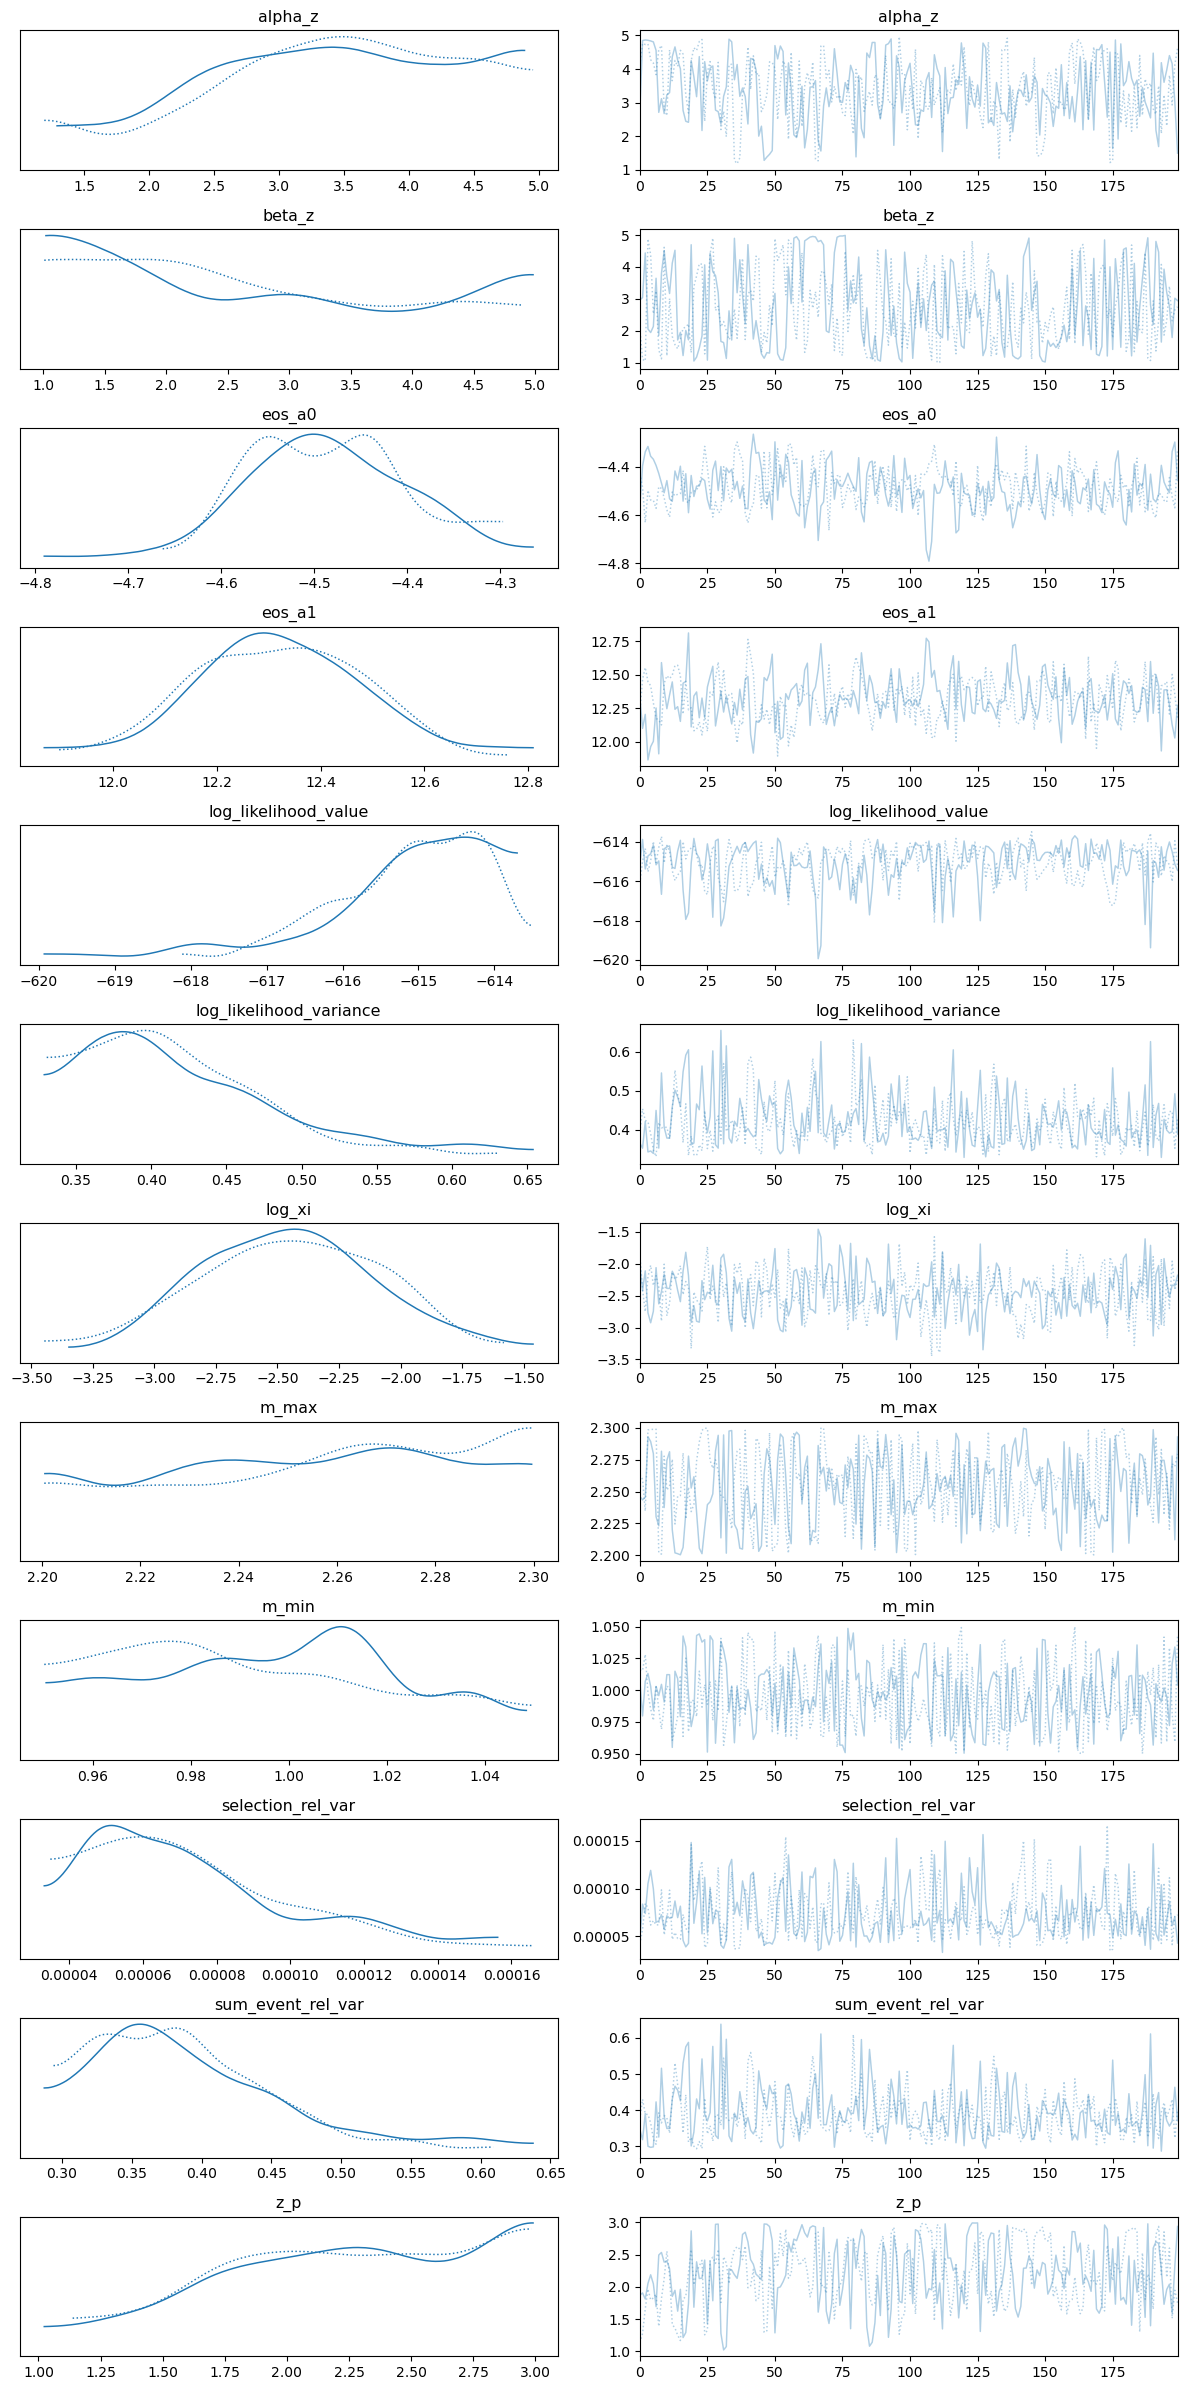

/var/folders/bz/qc_y_tmj1lv6v__5hy2s54x00000gn/T/ipykernel_44766/1850036722.py:107: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(


Running Poly 7 inference: EOS order 7


sample: 100%|██████████| 400/400 [05:04<00:00,  1.31it/s, 255 steps of size 1.96e-02. acc. prob=0.95] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
   alpha_z      3.41      0.87      3.41      2.24      4.93    210.43      1.02
    beta_z      2.79      1.16      2.66      1.03      4.50    349.99      1.00
    eos_a0     -0.01      0.01     -0.01     -0.02      0.01    487.04      1.00
    eos_a1     -0.00      0.01     -0.00     -0.02      0.01    313.72      1.01
    eos_a2     -3.69      0.08     -3.68     -3.81     -3.56    378.88      1.01
    eos_a3     27.68      0.39     27.65     27.13     28.38    168.87      1.01
    eos_a4    -84.71      1.10    -84.67    -86.81    -83.17    153.01      1.01
    eos_a5    131.22      1.59    131.16    128.77    133.81    189.81      1.02
    eos_a6   -105.12      1.44   -105.05   -107.69   -102.98    234.00      1.01
    eos_a7     42.12      0.80     42.13     40.88     43.52    336.56      1.00
     m_max      2.25      0.03      2.25      2.21      2.30    405.35      1.00
     m_min      0.99      0

/Users/Michi/opt/miniconda3/envs/pymc_v25_safe/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/Michi/opt/miniconda3/envs/pymc_v25_safe/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


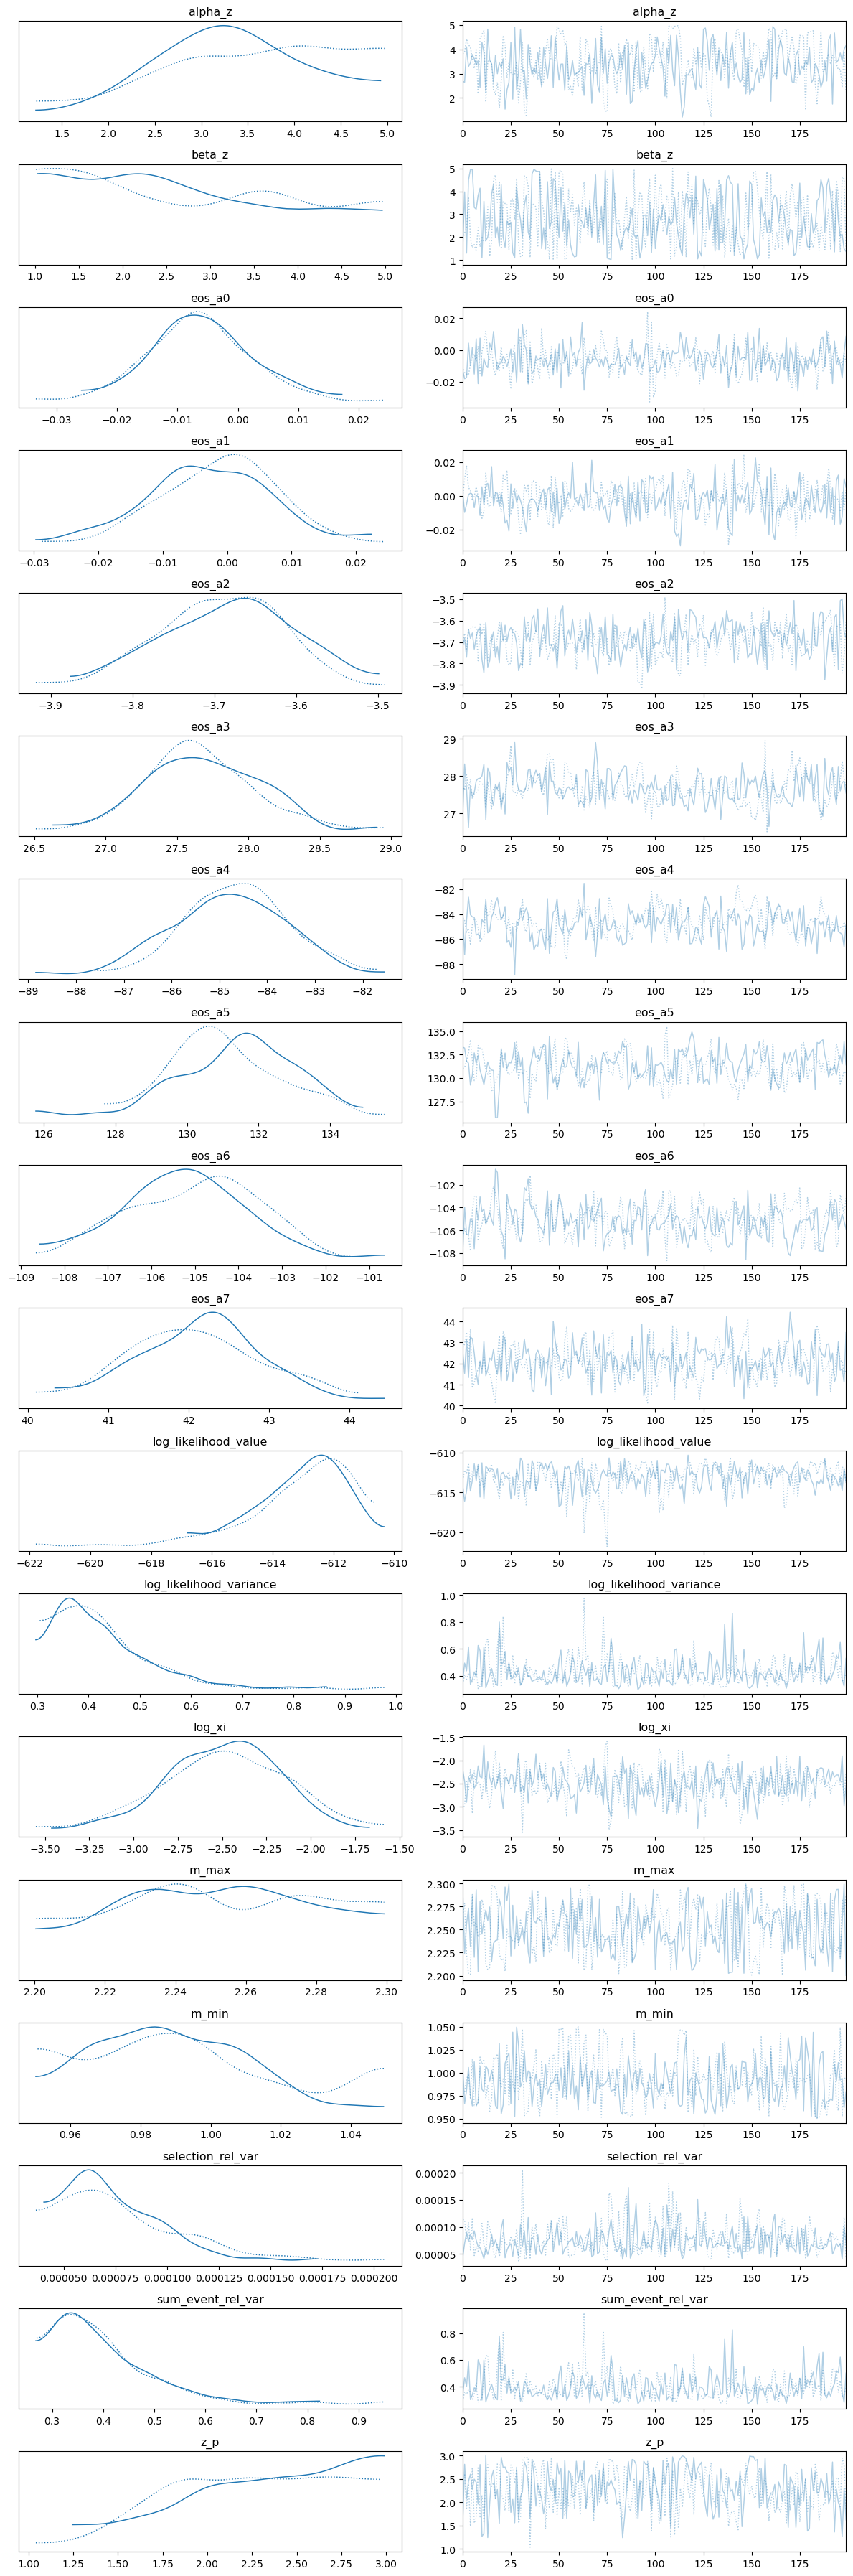

Completed misspecified EOS runs:
  Poly 1 inference: bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__eosmodel_poly1__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123
  Poly 7 inference: bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__eosmodel_poly7__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123


In [12]:
misspec_results = {}

for order in inference_eos_orders:
    label = f"Poly {order} inference"
    misspec_results[label] = run_inference_for_eos_order(order, label)

print("Completed misspecified EOS runs:")
for label, result in misspec_results.items():
    print(f"  {label}: {result['run_tag']}")

## Collect matched and misspecified results

In [13]:
def flatten_idata_posterior(idata):
    return {
        name: np.asarray(
            idata.posterior[name]
            .stack(sample=("chain", "draw"))
            .transpose("sample", ...)
            .values
        )
        for name in idata.posterior.data_vars
    }

all_results = {
    f"Matched poly {truth_eos_order}": {
        "label": f"Matched poly {truth_eos_order}",
        "order": truth_eos_order,
        "run_tag": matched_run_tag,
        "idata": matched_idata,
        "param_config": None,
    }
}
all_results.update(misspec_results)

for result in all_results.values():
    result["posterior"] = flatten_idata_posterior(result["idata"])

comparison_tag = f"{base_tag}__eosmisspec__{inf_tag}"
print(f"Comparison tag: {comparison_tag}")

Comparison tag: bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__eosmisspec__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123


## Helper functions for comparison diagnostics

In [14]:
def get_coeff_draws(posterior, order):
    return np.column_stack([
        np.asarray(posterior[f"eos_a{k}"])
        for k in range(order + 1)
    ])

def eos_loglambda_draws(posterior, order, m_grid):
    coeff_draws = get_coeff_draws(posterior, order)
    return np.array([
        np.polyval(coeff_draws[i], m_grid)
        for i in range(coeff_draws.shape[0])
    ])

def result_band(y_draws):
    return (
        np.percentile(y_draws, 5, axis=0),
        np.percentile(y_draws, 50, axis=0),
        np.percentile(y_draws, 95, axis=0),
    )

def bounded_smooth_mass_unnorm_np(m, m_min, m_max, edge_width, edge_pdf_value):
    logit_edge = np.log((1.0 - edge_pdf_value) / edge_pdf_value)
    edge_scale = edge_width / logit_edge
    left = 1.0 / (1.0 + np.exp(-(m - m_min - edge_width) / edge_scale))
    right = 1.0 / (1.0 + np.exp(-(m_max - edge_width - m) / edge_scale))
    return left * right

def mass_pdf_draws_from_posterior(posterior, m_grid):
    n_draws = len(next(iter(posterior.values())))
    pdf_draws = []
    for draw_id in range(n_draws):
        m_min_draw = float(posterior["m_min"][draw_id]) if "m_min" in posterior else m_min_true
        m_max_draw = float(posterior["m_max"][draw_id]) if "m_max" in posterior else m_max_true
        edge_width_draw = float(posterior["edge_width"][draw_id]) if "edge_width" in posterior else edge_width_true
        pdf = bounded_smooth_mass_unnorm_np(
            m_grid, m_min_draw, m_max_draw, edge_width_draw, edge_pdf_value
        )
        pdf /= np.trapz(pdf, m_grid)
        pdf_draws.append(pdf)
    return np.array(pdf_draws)

def median_coeffs(posterior, order):
    coeff_draws = get_coeff_draws(posterior, order)
    return np.median(coeff_draws, axis=0)

def lambda_tilde_np(m1, m2, lambda1, lambda2):
    return (16.0 / 13.0) * (
        (m1 + 12.0 * m2) * m1**4 * lambda1
        + (m2 + 12.0 * m1) * m2**4 * lambda2
    ) / (m1 + m2) ** 5

def divergence_count(idata):
    if "diverging" not in idata.sample_stats:
        return np.nan
    return int(np.asarray(idata.sample_stats["diverging"]).sum())

## EOS posterior comparison

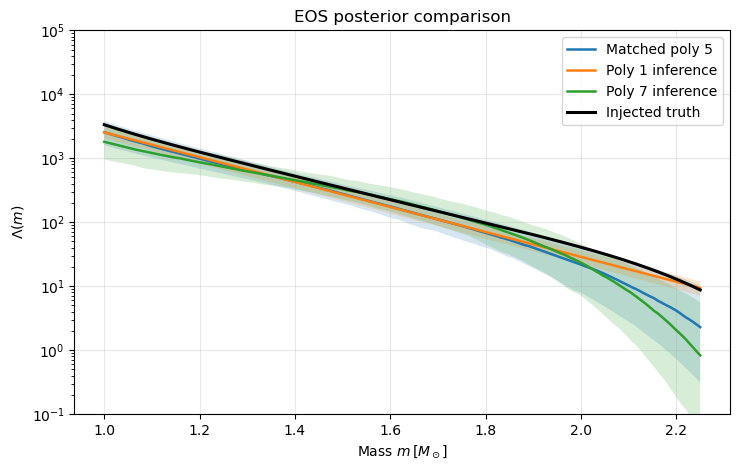

Saved EOS misspecification comparison to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/eos_misspec_comparison__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__eosmisspec__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.png


In [15]:
m_plot = np.linspace(fit_min, fit_max, 300)
loglambda_truth = np.polyval(eos_coeffs_fit, m_plot)
lambda_truth = np.exp(loglambda_truth)

fig, ax = plt.subplots(figsize=(7.5, 4.8))

for label, result in all_results.items():
    loglambda_draws = eos_loglambda_draws(result["posterior"], result["order"], m_plot)
    lambda_draws = np.exp(loglambda_draws)
    q05, q50, q95 = result_band(lambda_draws)
    ax.fill_between(m_plot, q05, q95, alpha=0.18)
    ax.plot(m_plot, q50, lw=1.8, label=label)

ax.plot(m_plot, lambda_truth, color="black", lw=2.2, label="Injected truth")
ax.set_yscale("log")
ax.set_ylim(0.1, 1e5)
ax.set_xlabel(r"Mass $m\,[M_\odot]$")
ax.set_ylabel(r"$\Lambda(m)$")
ax.set_title("EOS posterior comparison")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

path = figures_dir / f"eos_misspec_comparison__{comparison_tag}.png"
fig.savefig(path, dpi=200)
plt.show()
print(f"Saved EOS misspecification comparison to {path}")

## Function-space EOS bias comparison

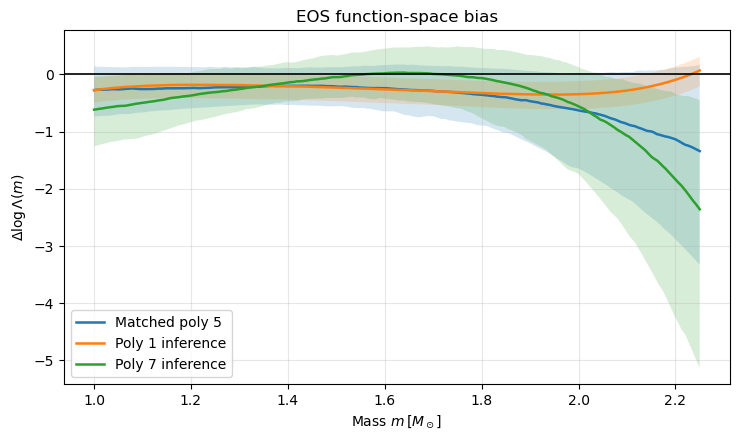

Saved EOS bias comparison to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/eos_misspec_bias__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__eosmisspec__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.png


In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

bias_rows = []

for label, result in all_results.items():
    loglambda_draws = eos_loglambda_draws(result["posterior"], result["order"], m_plot)
    delta = loglambda_draws - loglambda_truth[None, :]
    q05, q50, q95 = result_band(delta)
    ax.fill_between(m_plot, q05, q95, alpha=0.18)
    ax.plot(m_plot, q50, lw=1.8, label=label)

    bias_rows.append({
        "model": label,
        "eos_order": result["order"],
        "mean_abs_delta_loglambda": float(np.mean(np.abs(q50))),
        "max_abs_delta_loglambda": float(np.max(np.abs(q50))),
    })

ax.axhline(0.0, color="black", lw=1.2)
ax.set_xlabel(r"Mass $m\,[M_\odot]$")
ax.set_ylabel(r"$\Delta\log\Lambda(m)$")
ax.set_title("EOS function-space bias")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

path = figures_dir / f"eos_misspec_bias__{comparison_tag}.png"
fig.savefig(path, dpi=200)
plt.show()
print(f"Saved EOS bias comparison to {path}")

## Mass-distribution comparison

/var/folders/bz/qc_y_tmj1lv6v__5hy2s54x00000gn/T/ipykernel_44766/630664037.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_true /= np.trapz(pdf_true, m_mass)
/var/folders/bz/qc_y_tmj1lv6v__5hy2s54x00000gn/T/ipykernel_44766/330699269.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf /= np.trapz(pdf, m_grid)


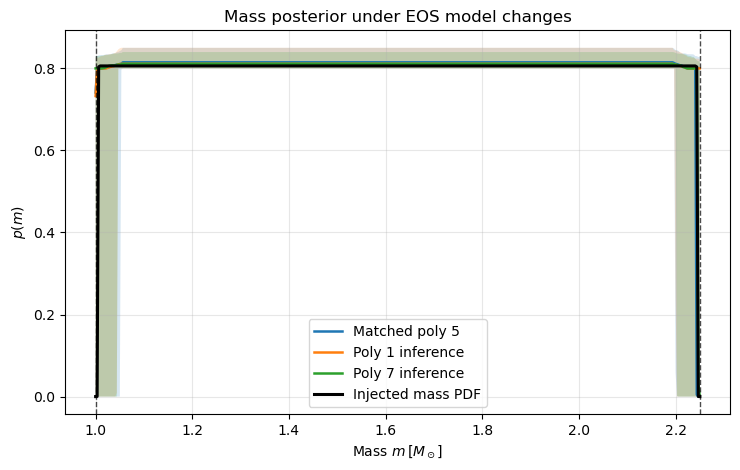

Saved mass misspecification comparison to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mass_misspec_comparison__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__eosmisspec__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.png


In [17]:
m_mass = np.linspace(fit_min, fit_max, 400)

pdf_true = bounded_smooth_mass_unnorm_np(
    m_mass, m_min_true, m_max_true, edge_width_true, edge_pdf_value
)
pdf_true /= np.trapz(pdf_true, m_mass)

fig, ax = plt.subplots(figsize=(7.5, 4.8))

for label, result in all_results.items():
    pdf_draws = mass_pdf_draws_from_posterior(result["posterior"], m_mass)
    q05, q50, q95 = result_band(pdf_draws)
    ax.fill_between(m_mass, q05, q95, alpha=0.18)
    ax.plot(m_mass, q50, lw=1.8, label=label)

ax.plot(m_mass, pdf_true, color="black", lw=2.2, label="Injected mass PDF")
ax.axvline(m_min_true, color="black", ls="--", lw=1.0, alpha=0.7)
ax.axvline(m_max_true, color="black", ls="--", lw=1.0, alpha=0.7)
ax.set_xlabel(r"Mass $m\,[M_\odot]$")
ax.set_ylabel(r"$p(m)$")
ax.set_title("Mass posterior under EOS model changes")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

path = figures_dir / f"mass_misspec_comparison__{comparison_tag}.png"
fig.savefig(path, dpi=200)
plt.show()
print(f"Saved mass misspecification comparison to {path}")

## Tidal residuals versus chirp mass

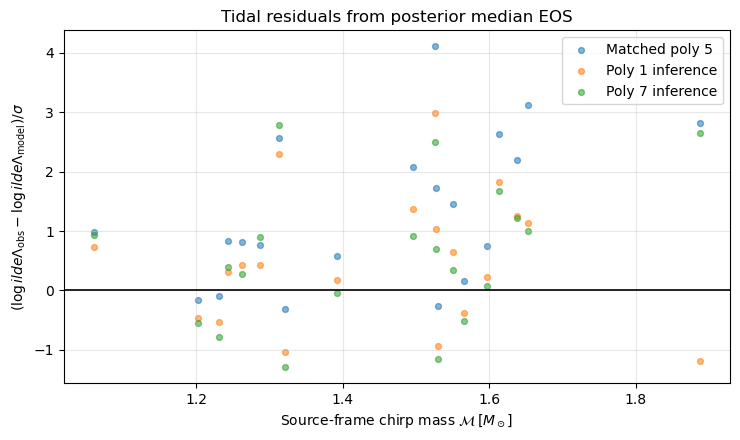

Saved tidal residual comparison to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/tidal_residuals_vs_mass__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__eosmisspec__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.png


In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

for label, result in all_results.items():
    coeff_med = median_coeffs(result["posterior"], result["order"])
    lambda1_med = np.exp(np.polyval(coeff_med, true_m1))
    lambda2_med = np.exp(np.polyval(coeff_med, true_m2))
    lambda_tilde_med = lambda_tilde_np(true_m1, true_m2, lambda1_med, lambda2_med)
    residual = (obs_log_lambdatilde - np.log(lambda_tilde_med)) / sigma_log_lambdatilde
    ax.scatter(true_mchirp, residual, s=18, alpha=0.55, label=label)

ax.axhline(0.0, color="black", lw=1.2)
ax.set_xlabel(r"Source-frame chirp mass $\mathcal{M}\,[M_\odot]$")
ax.set_ylabel(r"$(\log	ilde\Lambda_\mathrm{obs}-\log	ilde\Lambda_\mathrm{model})/\sigma$")
ax.set_title("Tidal residuals from posterior median EOS")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

path = figures_dir / f"tidal_residuals_vs_mass__{comparison_tag}.png"
fig.savefig(path, dpi=200)
plt.show()
print(f"Saved tidal residual comparison to {path}")

## Summary table

In [19]:
summary_rows = []
for row in bias_rows:
    label = row["model"]
    result = all_results[label]
    posterior = result["posterior"]

    summary_rows.append({
        "model": label,
        "eos_order": result["order"],
        "divergences": divergence_count(result["idata"]),
        "median_log_likelihood": float(np.median(posterior["log_likelihood_value"])),
        "median_log_likelihood_variance": float(np.median(posterior["log_likelihood_variance"])),
        "mean_abs_delta_loglambda": row["mean_abs_delta_loglambda"],
        "max_abs_delta_loglambda": row["max_abs_delta_loglambda"],
    })

comparison_summary = pd.DataFrame(summary_rows)
summary_path = results_dir / f"eos_misspec_summary__{comparison_tag}.csv"
comparison_summary.to_csv(summary_path, index=False)
print(f"Saved EOS misspecification summary to {summary_path}")
comparison_summary

Saved EOS misspecification summary to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/results/eos_misspec_summary__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__eosmisspec__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.csv


,model,eos_order,divergences,median_log_likelihood,median_log_likelihood_variance,mean_abs_delta_loglambda,max_abs_delta_loglambda
0,Matched poly 5,5,0,-614.447251,0.410244,0.422509,1.340470
1,Poly 1 inference,1,0,-614.963818,0.405395,0.246170,0.352794
2,Poly 7 inference,7,0,-612.713803,0.405900,0.442463,2.357694


In [20]:
# Model-comparison diagnostics.
#
# These are not Bayesian evidences. They are posterior diagnostic scores based on
# the sampled hierarchical log likelihood stored by the model.
#
# Definitions:
#   D(theta) = -2 log L(theta)
#   p_DIC_var = Var[D(theta)] / 2
#   DIC_var = mean[D(theta)] + p_DIC_var
#
# Lower DIC_var is better. Differences should be interpreted cautiously:
# the likelihood includes the selection correction and uses Monte Carlo estimates.

metric_rows = []

for label, result in all_results.items():
    posterior = result["posterior"]

    logL = np.asarray(posterior["log_likelihood_value"], dtype=float)
    logL_var = np.asarray(posterior["log_likelihood_variance"], dtype=float)
    log_xi_samples = np.asarray(posterior["log_xi"], dtype=float)

    finite = np.isfinite(logL)
    if not np.any(finite):
        raise RuntimeError(f"No finite log-likelihood samples for model {label}")

    logL = logL[finite]
    deviance = -2.0 * logL

    mean_deviance = np.mean(deviance)
    median_deviance = np.median(deviance)
    p_dic_var = 0.5 * np.var(deviance, ddof=1)
    dic_var = mean_deviance + p_dic_var

    metric_rows.append({
        "model": label,
        "eos_order": result["order"],
        "n_posterior_samples": len(logL),
        "divergences": divergence_count(result["idata"]),

        # Likelihood diagnostics
        "median_logL": np.median(logL),
        "q05_logL": np.quantile(logL, 0.05),
        "q95_logL": np.quantile(logL, 0.95),
        "mean_deviance": mean_deviance,
        "median_deviance": median_deviance,

        # DIC-like diagnostic
        "p_dic_var": p_dic_var,
        "dic_var": dic_var,

        # Selection / MC diagnostics
        "median_log_xi": np.median(log_xi_samples),
        "median_log_likelihood_variance": np.median(logL_var),
        "q95_log_likelihood_variance": np.quantile(logL_var, 0.95),
    })

model_metrics = pd.DataFrame(metric_rows)

# Differences relative to the matched model.
matched_label = f"Matched poly {truth_eos_order}"
if matched_label not in set(model_metrics["model"]):
    raise RuntimeError(f"Could not find matched reference model: {matched_label}")

matched_row = model_metrics.loc[model_metrics["model"] == matched_label].iloc[0]

model_metrics["delta_median_logL_vs_matched"] = (
    model_metrics["median_logL"] - matched_row["median_logL"]
)
model_metrics["delta_dic_var_vs_matched"] = (
    model_metrics["dic_var"] - matched_row["dic_var"]
)
model_metrics["delta_mean_deviance_vs_matched"] = (
    model_metrics["mean_deviance"] - matched_row["mean_deviance"]
)

# Add function-space bias metrics already computed in bias_rows.
bias_metrics = pd.DataFrame(bias_rows)
model_metrics = model_metrics.merge(
    bias_metrics[[
        "model",
        "mean_abs_delta_loglambda",
        "max_abs_delta_loglambda",
    ]],
    on="model",
    how="left",
)

# Sort by DIC-like score.
model_metrics = model_metrics.sort_values("dic_var").reset_index(drop=True)

metrics_path = results_dir / f"eos_misspec_model_metrics__{comparison_tag}.csv"
model_metrics.to_csv(metrics_path, index=False)

print(f"Saved EOS model-comparison metrics to {metrics_path}")
display(model_metrics)


# Automatic text conclusions.
best_by_dic = model_metrics.iloc[0]
best_by_logL = model_metrics.loc[model_metrics["median_logL"].idxmax()]

print("\nModel-comparison conclusions")
print("----------------------------")
print(
    f"Best DIC-like score: {best_by_dic['model']} "
    f"(DIC_var = {best_by_dic['dic_var']:.2f})."
)
print(
    f"Best median log likelihood: {best_by_logL['model']} "
    f"(median logL = {best_by_logL['median_logL']:.2f})."
)

for _, row in model_metrics.iterrows():
    if row["model"] == matched_label:
        continue

    print()
    print(f"{row['model']} compared with {matched_label}:")
    print(f"  Δ median logL = {row['delta_median_logL_vs_matched']:.2f}")
    print(f"  Δ DIC_var     = {row['delta_dic_var_vs_matched']:.2f}")
    print(f"  mean |Δ log Lambda| = {row['mean_abs_delta_loglambda']:.3f}")
    print(f"  max  |Δ log Lambda| = {row['max_abs_delta_loglambda']:.3f}")

    if abs(row["delta_median_logL_vs_matched"]) < 2.0 and abs(row["delta_dic_var_vs_matched"]) < 5.0:
        print("  Interpretation: practically indistinguishable from the matched model in this run.")
    elif row["delta_median_logL_vs_matched"] < -2.0 or row["delta_dic_var_vs_matched"] > 5.0:
        print("  Interpretation: disfavored relative to the matched model by these diagnostics.")
    else:
        print("  Interpretation: weak or ambiguous preference; inspect residual and bias plots.")

Saved EOS model-comparison metrics to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/results/eos_misspec_model_metrics__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__eosmisspec__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.csv


,model,eos_order,n_posterior_samples,divergences,median_logL,q05_logL,q95_logL,mean_deviance,median_deviance,p_dic_var,dic_var,median_log_xi,median_log_likelihood_variance,q95_log_likelihood_variance,delta_median_logL_vs_matched,delta_dic_var_vs_matched,delta_mean_deviance_vs_matched,mean_abs_delta_loglambda,max_abs_delta_loglambda
0,Poly 7 inference,7,400,0,-612.713803,-615.959363,-611.092036,1226.120773,1225.427606,5.119585,1231.240358,-2.476412,0.405900,0.610149,1.733447,-2.746743,-2.874874,0.442463,2.357694
1,Poly 1 inference,1,400,0,-614.963818,-617.024441,-613.908762,1230.220518,1229.927635,2.122739,1232.343257,-2.447094,0.405395,0.552007,-0.516567,-1.643843,1.224871,0.246170,0.352794
2,Matched poly 5,5,400,0,-614.447251,-617.312834,-612.051922,1228.995647,1228.894501,4.991454,1233.987101,-2.454066,0.410244,0.600270,0.000000,0.000000,0.000000,0.422509,1.340470



Model-comparison conclusions
----------------------------
Best DIC-like score: Poly 7 inference (DIC_var = 1231.24).
Best median log likelihood: Poly 7 inference (median logL = -612.71).

Poly 7 inference compared with Matched poly 5:
  Δ median logL = 1.73
  Δ DIC_var     = -2.75
  mean |Δ log Lambda| = 0.442
  max  |Δ log Lambda| = 2.358
  Interpretation: practically indistinguishable from the matched model in this run.

Poly 1 inference compared with Matched poly 5:
  Δ median logL = -0.52
  Δ DIC_var     = -1.64
  mean |Δ log Lambda| = 0.246
  max  |Δ log Lambda| = 0.353
  Interpretation: practically indistinguishable from the matched model in this run.
